In [3]:
%pip install datasets evaluate
%pip install transformers[torch]
%pip install accelerate -U

In [1]:
import torch

device = "gpu" if torch.cuda.is_available() else "cpu"

# 1 Data preparation

In [4]:
!pip install -U datasets fsspec


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 16.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.


In [5]:
from datasets import load_dataset

imdb = load_dataset("imdb")

id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def processed_funtion(examples):
    return tokenizer(examples["text"], truncation=True)

tokenized_imdb = imdb.map(processed_funtion, batch_size=True, num_proc=10)

Map (num_proc=10):   0%|          | 0/25000 [00:00<?, ? examples/s]

Map (num_proc=10):   0%|          | 0/25000 [00:00<?, ? examples/s]

Map (num_proc=10):   0%|          | 0/50000 [00:00<?, ? examples/s]

In [7]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 2 Model

In [8]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased",
                                                           num_labels=2,
                                                           id2label=id2label,
                                                           label2id=label2id)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


# 3 Training

In [10]:
import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

In [13]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="out_dir",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_imdb["train"],
    eval_dataset=tokenized_imdb["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

/tmp/ipython-input-13-3102878852.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.182500,0.196326,0.924320
2,0.129400,0.212815,0.930560
3,0.084200,0.261177,0.930320
4,0.046700,0.309768,0.930560
5,0.035300,0.321619,0.929520


TrainOutput(global_step=3910, training_loss=0.09693828177878924, metrics={'train_runtime': 7712.0327, 'train_samples_per_second': 16.208, 'train_steps_per_second': 0.507, 'total_flos': 1.6551451665342624e+16, 'train_loss': 0.09693828177878924, 'epoch': 5.0})

In [14]:
trainer.evaluate(tokenized_imdb["test"])

{'eval_loss': 0.19632552564144135,
 'eval_accuracy': 0.92432,
 'eval_runtime': 379.6217,
 'eval_samples_per_second': 65.855,
 'eval_steps_per_second': 2.06,
 'epoch': 5.0}

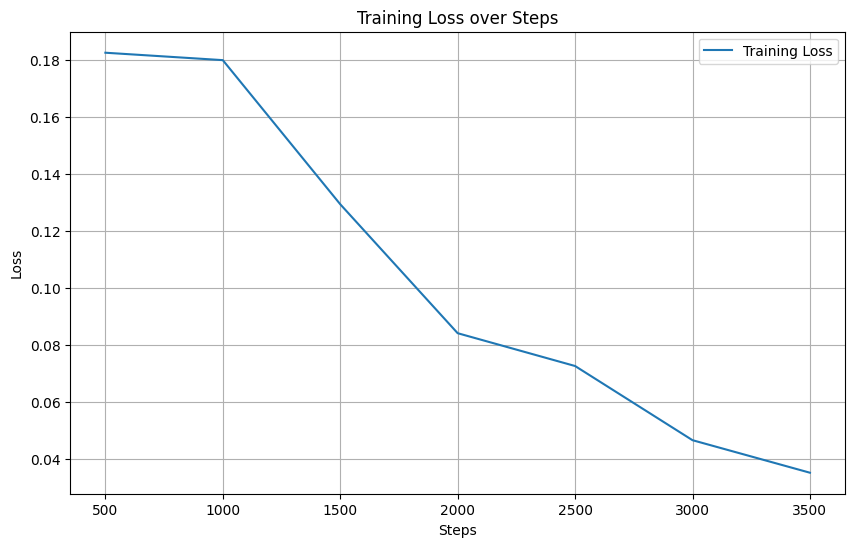

In [16]:
import matplotlib.pyplot as plt

# Extract the training loss from the trainer's logs
log_history = trainer.state.log_history
train_loss = [log['loss'] for log in log_history if 'loss' in log]
steps = [log['step'] for log in log_history if 'loss' in log]


# Plot the training loss
plt.figure(figsize=(10, 6))
plt.plot(steps, train_loss, label='Training Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss over Steps')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Example of making predictions
text_to_predict = ["This movie was fantastic! I loved every minute of it.",
                   "The acting was terrible and the plot was boring."]

# Tokenize the new text data
tokenized_text = tokenizer(text_to_predict, truncation=True, padding=True, return_tensors="pt")

# Move tokens to the same device as the model
tokenized_text = {k: v.to(trainer.args.device) for k, v in tokenized_text.items()}

# Make predictions
outputs = trainer.model(**tokenized_text)

# Get the predicted class (0 for negative, 1 for positive)
predictions = torch.argmax(outputs.logits, dim=-1)

# Convert predicted class IDs to labels
predicted_labels = [trainer.model.config.id2label[p.item()] for p in predictions]

for text, label in zip(text_to_predict, predicted_labels):
    print(f"Text: {text}\nPredicted label: {label}\n")

Text: This movie was fantastic! I loved every minute of it.
Predicted label: POSITIVE

Text: The acting was terrible and the plot was boring.
Predicted label: NEGATIVE



In [18]:
# Save the trained model
trainer.save_model("/content/drive/MyDrive/Colab Notebooks/Text_cls_huggingface/my_imdb_model")

In [19]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Define the path where the model was saved
saved_model_path = "/content/drive/MyDrive/Colab Notebooks/Text_cls_huggingface/my_imdb_model"

# Load the tokenizer from the saved model path
loaded_tokenizer = AutoTokenizer.from_pretrained(saved_model_path)

# Load the model from the saved model path
loaded_model = AutoModelForSequenceClassification.from_pretrained(saved_model_path)

# Example of making predictions with the loaded model
text_to_predict = ["This movie was fantastic! I loved every minute of it.",
                   "The acting was terrible and the plot was boring."]

# Tokenize the new text data using the loaded tokenizer
tokenized_text_loaded = loaded_tokenizer(text_to_predict, truncation=True, padding=True, return_tensors="pt")

# Move tokens to the same device as the loaded model (assuming GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
loaded_model.to(device)
tokenized_text_loaded = {k: v.to(device) for k, v in tokenized_text_loaded.items()}


# Make predictions with the loaded model
outputs_loaded = loaded_model(**tokenized_text_loaded)

# Get the predicted class (0 for negative, 1 for positive) from the loaded model's output
predictions_loaded = torch.argmax(outputs_loaded.logits, dim=-1)

# Convert predicted class IDs to labels using the loaded model's config
predicted_labels_loaded = [loaded_model.config.id2label[p.item()] for p in predictions_loaded]

for text, label in zip(text_to_predict, predicted_labels_loaded):
    print(f"Text: {text}\nPredicted label (loaded model): {label}\n")

Text: This movie was fantastic! I loved every minute of it.
Predicted label (loaded model): POSITIVE

Text: The acting was terrible and the plot was boring.
Predicted label (loaded model): NEGATIVE

